# Validating kinGEMs Pipeline on $E. coli$ iML1515 Model

This notebook validates the metabolic flux predictions ecGEMs constructed with kinGEMs against experimental flux data. 

The experimental data comes from the study of Crown et al. (2015). It corresponds to measured metabolic fluxes using 13C metabolic flux analysis (13C-MFA). The studied organism was a W3110 strain of *E. coli*, grown on M9 media.

---
S. B. Crown, C. P. Long, and M. R. Antoniewicz, “Integrated 13 C-metabolic flux analysis of 14 parallel labeling experiments in Escherichia coli,” Metabolic Engineering, vol. 28, pp. 151–158, Jan. 2015, doi: 10.1016/j.ymben.2015.01.001.

In [1]:
# Automatic module reloading
%load_ext autoreload
%autoreload 2

# Packages
import os
import sys
import pandas as pd 
import matplotlib.pyplot as plt 
import cobra 
import numpy as np 
from datetime import datetime
import cobra as cb
import random

# Add parent directory 
sys.path.append(os.path.abspath('..'))

# Import kinGEMs components
import kinGEMs
from kinGEMs.dataset import process_kcat_predictions, annotate_model_with_kcat_and_gpr
from kinGEMs.modeling.optimize import run_optimization_with_dataframe, validate_enzyme_constraints
from kinGEMs.fluxomics_validation import compare_fluxomics, apply_ecomics_condition, get_medium_dict
from kinGEMs.modeling.tuning import simulated_annealing
from kinGEMs.plots import plot_flux_correlation, plot_flux_differences

# Paths
processed_data_dir = os.path.join("../data", "processed")
experimental_data_dir = os.path.join("../data", "experimental")
model_xml = os.path.join("../models", f"iML1515_GEM.xml")
processed_data_csv = os.path.join(processed_data_dir,"ecoli_iML1515","ecoli_iML1515_processed_data.csv")


2025-10-23 11:11:48.647 | INFO     | kinGEMs.config:<module>:12 - PROJ_ROOT path is: C:\Users\Rana\OneDrive\Documents\GitHub\kinGEMs_v2


Set parameter Username
Academic license - for non-commercial use only - expires 2026-02-25


## Run optimization with regular model

Unconstrained model biomass ~0.87

Constrained model biomass ~0.039 (when using 0.15 for enzyme_upper_bound)

Constrained model biomass ~0.13 (when using 0.3 for enzyme_upper_bound)

In [2]:
# Model and data
processed_data = pd.read_csv(processed_data_csv)
model = cb.io.read_sbml_model(model_xml)

# Simulation parameters
biomass_reaction = 'BIOMASS_Ec_iML1515_core_75p37M' 
enzyme_upper_bound = 0.3

In [3]:
print("=== Annotating model with kcat and GPR ===")
model = annotate_model_with_kcat_and_gpr(
    model=model,
    df=processed_data
)

=== Annotating model with kcat and GPR ===


In [4]:
# Diagnostic: Before kcat annotation
print("[Step] After annotate_model_with_kcat_and_gpr:")
print("  Genes in model:", len(model.genes))
print("  Reactions in model:", len(model.reactions))
model_gene_ids = set([g.id for g in model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After annotate_model_with_kcat_and_gpr:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b0463', 'b0774', 'b4006', 'b1473', 'b4323', 'b0978', 'b0402', 'b1033', 'b1296', 'b0004']
  First 10 reaction IDs: ['3OAR60', 'RBK_L1', 'ILEt3pp', 'THFAT', 'U23GAAT', 'UGLYCH', 'GSNK', '23PDE9pp', 'GDPMNP', 'MDH2']
  Reactions with kcat: 2136
  Reactions without kcat: 576


In [5]:
print("=== Running optimization with kcat constraints ===")
(solution_value_regular, df_FBA_regular, gene_sequences_dict_regular, _)=run_optimization_with_dataframe(
    model=model, 
    processed_df=processed_data, 
    objective_reaction=biomass_reaction, 
    enzyme_upper_bound=enzyme_upper_bound, 
    enzyme_ratio=True, 
    maximization=True, 
    multi_enzyme_off=False, 
    isoenzymes_off=False, 
    promiscuous_off=False, 
    complexes_off=False,
    output_dir=None, 
    save_results=False,
    print_reaction_conditions=True,
    verbose=False)

print("Biomass value: ", solution_value_regular)

=== Running optimization with kcat constraints ===
Biomass value:  0.130813357048967


In [6]:
# Diagnostic: After optimization step
print("[Step] After run_optimization_with_dataframe:")
print("  Genes in model:", len(model.genes))
print("  Reactions in model:", len(model.reactions))
model_gene_ids = set([g.id for g in model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After run_optimization_with_dataframe:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b0463', 'b0774', 'b4006', 'b1473', 'b4323', 'b0978', 'b0402', 'b1033', 'b1296', 'b0004']
  First 10 reaction IDs: ['3OAR60', 'RBK_L1', 'ILEt3pp', 'THFAT', 'U23GAAT', 'UGLYCH', 'GSNK', '23PDE9pp', 'GDPMNP', 'MDH2']
  Reactions with kcat: 2136
  Reactions without kcat: 576


In [11]:
out_path_regular = os.path.join("../notebooks", 
                        "results", 
                        "exp_validation_results", 
                        "W3110_MD121_M9+Glu_none", 
                        "df_FBA_regular_model.csv")

df_FBA_regular.to_csv(out_path_regular, index=False)

## Run optimization with modified model

The GEM's lower bounds are modified to match the experimental uptake and secretion rates.


Unconstrained model biomass ~0.87

Constrained model biomass ~0.039 (when using 0.15 for enzyme_upper_bound)

Constrained model biomass ~0.13 (when using 0.3 for enzyme_upper_bound)


In [12]:
# Model and data
processed_data = pd.read_csv(processed_data_csv)
mod_model = cb.io.read_sbml_model(model_xml)

# Simulation parameters
biomass_reaction = 'BIOMASS_Ec_iML1515_core_75p37M' 
enzyme_upper_bound = 0.3

In [13]:
# Diagnostic: Before optimization step
print("[Step] After run_optimization_with_dataframe:")
print("  Genes in model:", len(mod_model.genes))
print("  Reactions in model:", len(mod_model.reactions))
model_gene_ids = set([g.id for g in mod_model.genes])
model_rxn_ids = set([r.id for r in mod_model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in mod_model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After run_optimization_with_dataframe:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b0463', 'b0774', 'b4006', 'b1473', 'b4323', 'b0978', 'b0402', 'b1033', 'b1296', 'b0004']
  First 10 reaction IDs: ['3OAR60', 'RBK_L1', 'ILEt3pp', 'THFAT', 'U23GAAT', 'UGLYCH', 'GSNK', '23PDE9pp', 'GDPMNP', 'MDH2']
  Reactions with kcat: 0
  Reactions without kcat: 2712


In [14]:
print("=== Annotating model with kcat and GPR ===")
mod_annotated_model = annotate_model_with_kcat_and_gpr(
    model=mod_model,
    df=processed_data
)

=== Annotating model with kcat and GPR ===


In [15]:
# Get the M9+Glu medium composition
medium = get_medium_dict('MD121')
print("Medium dictionary:", medium)

Medium dictionary: {'EX_glc__D_e': -10, 'EX_so4_e': -1.699, 'EX_o2_e': -14.49, 'EX_nh4_e': -5.229, 'EX_h2o_e': -6.96}


In [16]:
print("=== Running optimization with kcat constraints ===")
(solution_value_modified, df_FBA_modified, gene_sequences_dict_modified, _)=run_optimization_with_dataframe(
    model=mod_annotated_model, 
    processed_df=processed_data, 
    objective_reaction=biomass_reaction, 
    enzyme_upper_bound=enzyme_upper_bound, 
    enzyme_ratio=True, 
    maximization=True, 
    multi_enzyme_off=False, 
    isoenzymes_off=False, 
    promiscuous_off=False, 
    complexes_off=False,
    output_dir=None, 
    save_results=False,
    print_reaction_conditions=True,
    verbose=True,
    medium=medium)

print("Biomass value: ", solution_value_modified)

=== Running optimization with kcat constraints ===

=== DIAGNOSTIC: Checking captured bounds ===
  EX_glc__D_e lower bound in lb dict: -10.0000 (should be -10.0000)
  EX_glc__D_e upper bound in ub dict: -10.0000 (should be -10.0000)
  EX_so4_e lower bound in lb dict: -1.6990 (should be -1.6990)
  EX_so4_e upper bound in ub dict: -1.6990 (should be -1.6990)
  EX_o2_e lower bound in lb dict: -14.4900 (should be -14.4900)
  EX_o2_e upper bound in ub dict: -14.4900 (should be -14.4900)
  EX_nh4_e lower bound in lb dict: -5.2290 (should be -5.2290)
  EX_nh4_e upper bound in ub dict: -5.2290 (should be -5.2290)
  EX_h2o_e lower bound in lb dict: -6.9600 (should be -6.9600)
  EX_h2o_e upper bound in ub dict: -6.9600 (should be -6.9600)
=== END DIAGNOSTIC ===

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --tmlim 300 --write C:\Users\Rana\AppData\Local\Temp\tmpdykm6ikv.glpk.raw
 --wglp C:\Users\Rana\AppData\Local\Temp\tmplq3u0s1t.glpk.glp --cpxlp C:\Users\Rana\App

In [17]:
# Diagnostic: After optimization step
print("[Step] After run_optimization_with_dataframe:")
print("  Genes in model:", len(mod_annotated_model.genes))
print("  Reactions in model:", len(mod_annotated_model.reactions))
model_gene_ids = set([g.id for g in mod_annotated_model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in mod_annotated_model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After run_optimization_with_dataframe:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b0463', 'b0774', 'b4006', 'b1473', 'b4323', 'b0978', 'b0402', 'b1033', 'b1296', 'b0004']
  First 10 reaction IDs: ['3OAR60', 'RBK_L1', 'ILEt3pp', 'THFAT', 'U23GAAT', 'UGLYCH', 'GSNK', '23PDE9pp', 'GDPMNP', 'MDH2']
  Reactions with kcat: 2136
  Reactions without kcat: 576


In [18]:
out_path_modified = os.path.join("../notebooks", 
                        "results", 
                        "exp_validation_results", 
                        "W3110_MD121_M9+Glu_none", 
                        "df_FBA_modified_model.csv")

df_FBA_modified.to_csv(out_path_modified, index=False)

### Comparing kinGEMs biomass to COBRApy biomass (FBA, no kcat constraints)

COBRApy biomass with matching media ~0.48

In [19]:

# Model
model = cb.io.read_sbml_model(model_xml)

# Simulation parameters
biomass_reaction = 'BIOMASS_Ec_iML1515_core_75p37M' 

print("=== Apply medium changes to model ===")
mod_model = apply_ecomics_condition(model=model, 
                                    medium_id='MD121', 
                                    stress='none')

print("=== Run COBRApy FBA ===")
cobrapy_solution = mod_model.optimize()
print(f"Biomass (FBA):{cobrapy_solution.objective_value}")

=== Apply medium changes to model ===
Applying M9+Glu medium
Set EX_glc__D_e lower bound to -10
Set EX_glc__D_e upper bound to -10
Set EX_so4_e lower bound to -1.699
Set EX_so4_e upper bound to -1.699
Set EX_o2_e lower bound to -14.49
Set EX_o2_e upper bound to -14.49
Set EX_nh4_e lower bound to -5.229
Set EX_nh4_e upper bound to -5.229
Set EX_h2o_e lower bound to -6.96
Set EX_h2o_e upper bound to -6.96
=== Run COBRApy FBA ===
Biomass (FBA):0.22113660402569618


In [20]:
# Create df of fluxes
cobrapy_fluxes_df = pd.DataFrame({
    "Variable": "flux",
    "Index": cobrapy_solution.fluxes.index,
    "Value": cobrapy_solution.fluxes.values
})

out_path_cobrapy = os.path.join("../notebooks", 
                        "results", 
                        "exp_validation_results", 
                        "W3110_MD121_M9+Glu_none", 
                        "df_FBA_cobrapy.csv")

cobrapy_fluxes_df.to_csv(out_path_cobrapy, index=False)

# Simulated annealing

In [21]:
# Model and data
processed_data = pd.read_csv(processed_data_csv)
model = cb.io.read_sbml_model(model_xml)

# Simulation parameters
biomass_reaction = 'BIOMASS_Ec_iML1515_core_75p37M' 
enzyme_upper_bound = 0.3

In [22]:
# Diagnostic: Before optimization step
print("[Step] After run_optimization_with_dataframe:")
print("  Genes in model:", len(model.genes))
print("  Reactions in model:", len(model.reactions))
model_gene_ids = set([g.id for g in model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After run_optimization_with_dataframe:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b0463', 'b0774', 'b4006', 'b1473', 'b4323', 'b0978', 'b0402', 'b1033', 'b1296', 'b0004']
  First 10 reaction IDs: ['3OAR60', 'RBK_L1', 'ILEt3pp', 'THFAT', 'U23GAAT', 'UGLYCH', 'GSNK', '23PDE9pp', 'GDPMNP', 'MDH2']
  Reactions with kcat: 0
  Reactions without kcat: 2712


In [23]:
print("=== Annotating model with kcat and GPR ===")
mod_annotated_model = annotate_model_with_kcat_and_gpr(
    model=model,
    df=processed_data
)

=== Annotating model with kcat and GPR ===


In [24]:
# Get the M9+Glu medium composition
medium = get_medium_dict('MD121')
print("Medium dictionary:", medium)

Medium dictionary: {'EX_glc__D_e': -10, 'EX_so4_e': -1.699, 'EX_o2_e': -14.49, 'EX_nh4_e': -5.229, 'EX_h2o_e': -6.96}


In [25]:
print("=== Running optimization with kcat constraints ===")
(solution_value_modified, df_FBA_modified, gene_sequences_dict_modified, _)=run_optimization_with_dataframe(
    model=mod_annotated_model, 
    processed_df=processed_data, 
    objective_reaction=biomass_reaction, 
    enzyme_upper_bound=enzyme_upper_bound, 
    enzyme_ratio=True, 
    maximization=True, 
    multi_enzyme_off=False, 
    isoenzymes_off=False, 
    promiscuous_off=False, 
    complexes_off=False,
    output_dir=None, 
    save_results=False,
    print_reaction_conditions=True,
    verbose=False,
    medium=medium)

print("Biomass value: ", solution_value_modified)

=== Running optimization with kcat constraints ===

=== DIAGNOSTIC: Checking captured bounds ===
  EX_glc__D_e lower bound in lb dict: -10.0000 (should be -10.0000)
  EX_glc__D_e upper bound in ub dict: -10.0000 (should be -10.0000)
  EX_so4_e lower bound in lb dict: -1.6990 (should be -1.6990)
  EX_so4_e upper bound in ub dict: -1.6990 (should be -1.6990)
  EX_o2_e lower bound in lb dict: -14.4900 (should be -14.4900)
  EX_o2_e upper bound in ub dict: -14.4900 (should be -14.4900)
  EX_nh4_e lower bound in lb dict: -5.2290 (should be -5.2290)
  EX_nh4_e upper bound in ub dict: -5.2290 (should be -5.2290)
  EX_h2o_e lower bound in lb dict: -6.9600 (should be -6.9600)
  EX_h2o_e upper bound in ub dict: -6.9600 (should be -6.9600)
=== END DIAGNOSTIC ===


=== DIAGNOSTIC: Exchange reaction fluxes after optimization ===
  EX_glc__D_e: flux = -10.0000 (bound was -10.0000)
  EX_so4_e: flux = -1.6990 (bound was -1.6990)
  EX_o2_e: flux = -14.4900 (bound was -14.4900)
  EX_nh4_e: flux = -5.229

In [26]:
# Diagnostic: After optimization step
print("[Step] After run_optimization_with_dataframe:")
print("  Genes in model:", len(mod_annotated_model.genes))
print("  Reactions in model:", len(mod_annotated_model.reactions))
model_gene_ids = set([g.id for g in mod_annotated_model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in mod_annotated_model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After run_optimization_with_dataframe:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b0463', 'b0774', 'b4006', 'b1473', 'b4323', 'b0978', 'b0402', 'b1033', 'b1296', 'b0004']
  First 10 reaction IDs: ['3OAR60', 'RBK_L1', 'ILEt3pp', 'THFAT', 'U23GAAT', 'UGLYCH', 'GSNK', '23PDE9pp', 'GDPMNP', 'MDH2']
  Reactions with kcat: 2136
  Reactions without kcat: 576


===Running simulated annealing ===

=== DIAGNOSTIC: Checking captured bounds ===
  EX_glc__D_e lower bound in lb dict: -10.0000 (should be -10.0000)
  EX_glc__D_e upper bound in ub dict: -10.0000 (should be -10.0000)
  EX_so4_e lower bound in lb dict: -1.6990 (should be -1.6990)
  EX_so4_e upper bound in ub dict: -1.6990 (should be -1.6990)
  EX_o2_e lower bound in lb dict: -14.4900 (should be -14.4900)
  EX_o2_e upper bound in ub dict: -14.4900 (should be -14.4900)
  EX_nh4_e lower bound in lb dict: -5.2290 (should be -5.2290)
  EX_nh4_e upper bound in ub dict: -5.2290 (should be -5.2290)
  EX_h2o_e lower bound in lb dict: -6.9600 (should be -6.9600)
  EX_h2o_e upper bound in ub dict: -6.9600 (should be -6.9600)
=== END DIAGNOSTIC ===


=== DIAGNOSTIC: Exchange reaction fluxes after optimization ===
  EX_glc__D_e: flux = -10.0000 (bound was -10.0000)
  EX_so4_e: flux = -1.6990 (bound was -1.6990)
  EX_o2_e: flux = -14.4900 (bound was -14.4900)
  EX_nh4_e: flux = -5.2290 (bound was -5.

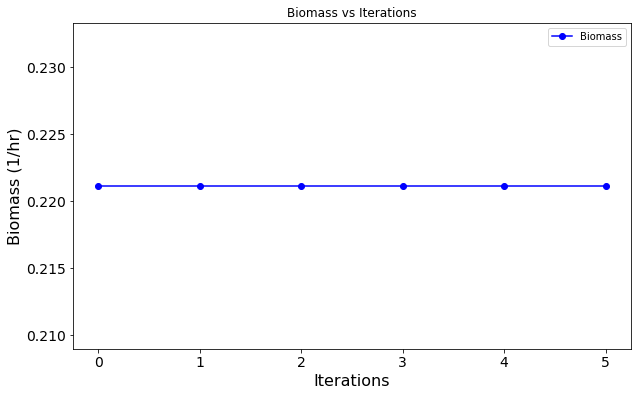

In [27]:
# === Configuration ===
organism_strain_GEMname = "ecoli_iML1515" # Update this
run_id = f"{organism_strain_GEMname}_{datetime.today().strftime('%Y%m%d')}"
tuning_results_dir = os.path.join("../notebooks", "results", "tuning_results", run_id)

print("===Running simulated annealing ===")
temperature = 1.0
cooling_rate = 0.975
min_temperature = 0.001
max_iterations = 100
max_unchanged_iterations = 5
change_threshold = 0.009
biomass_goal = 0.87

kcat_dict, top_targets, df_new, iterations, biomasses, df_FBA_modified_tuned = simulated_annealing(
    model=mod_annotated_model,
    processed_data=processed_data,
    biomass_reaction=biomass_reaction,
    objective_value=biomass_goal,
    gene_sequences_dict=gene_sequences_dict_modified,      # ← new
    output_dir=tuning_results_dir,
    enzyme_fraction=enzyme_upper_bound,
    temperature=temperature,
    cooling_rate=cooling_rate,
    min_temperature=min_temperature,
    max_iterations=max_iterations,
    max_unchanged_iterations=max_unchanged_iterations,
    change_threshold=change_threshold,
    medium=medium
)

print(f"Final biomass: {biomasses[-1]:.4f}")
print(f"Improvement: {(biomasses[-1] - biomasses[0]) / biomasses[0] * 100:.1f}%")
print("Top 10 enzymes by mass contribution:")
print(top_targets[['Reactions','Single_gene','enzyme_mass']])

In [28]:
# Diagnostic: After optimization step
print("[Step] After run_optimization_with_dataframe:")
print("  Genes in model:", len(mod_annotated_model.genes))
print("  Reactions in model:", len(mod_annotated_model.reactions))
model_gene_ids = set([g.id for g in mod_annotated_model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in mod_annotated_model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After run_optimization_with_dataframe:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b0463', 'b0774', 'b4006', 'b1473', 'b4323', 'b0978', 'b0402', 'b1033', 'b1296', 'b0004']
  First 10 reaction IDs: ['3OAR60', 'RBK_L1', 'ILEt3pp', 'THFAT', 'U23GAAT', 'UGLYCH', 'GSNK', '23PDE9pp', 'GDPMNP', 'MDH2']
  Reactions with kcat: 2136
  Reactions without kcat: 576


In [29]:
out_path_modified_tuned = os.path.join("../notebooks", 
                        "results", 
                        "exp_validation_results", 
                        "W3110_MD121_M9+Glu_none", 
                        "df_FBA_modified_model_tuned.csv")

df_FBA_modified_tuned.to_csv(out_path_modified_tuned, index=False)

# Correlation to experimental fluxes

In [30]:
from kinGEMs.plots import plot_flux_correlation, plot_flux_differences

In [31]:
# Crown experiment
experiment = 'W3110_MD121_M9+Glu_none'
experimental_fluxes_path = os.path.join(experimental_data_dir, f"fluxes_{experiment}.csv")

### Regular

Loaded 2712 FBA flux results
Loaded 143 experimental flux measurements
Merged dataframe has 2712 rows
Matched reactions: 143
Unmatched reactions: 2569


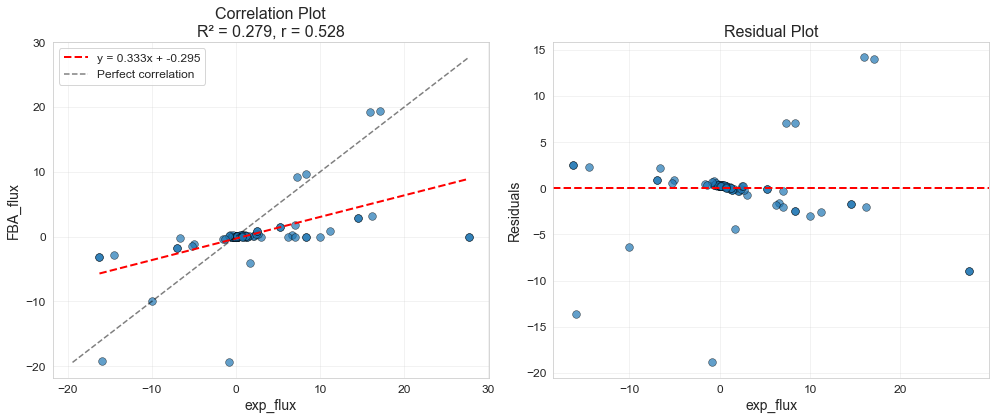

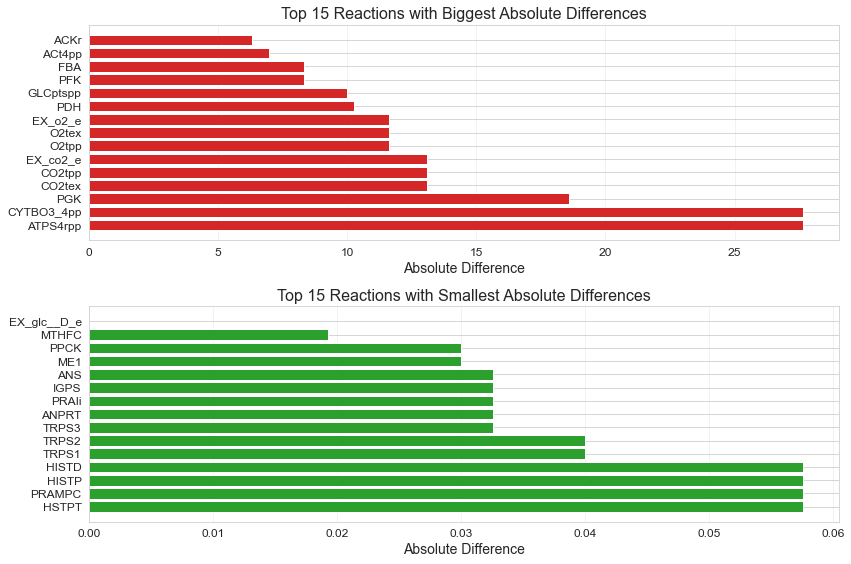

In [33]:
regular_exp_validation_df = compare_fluxomics(fba_results_path=out_path_regular, 
                                      exp_fluxes_path=experimental_fluxes_path)

# Correlation plot
fig, results = plot_flux_correlation(regular_exp_validation_df, 'exp_flux', 'FBA_flux', 
                                    output_path=None, show=True)

# Difference analysis
fig, diff_data = plot_flux_differences(regular_exp_validation_df, 'exp_flux', 'FBA_flux', top_n=15, 
                                      difference_type='absolute', show=True)

### Modified

Loaded 2712 FBA flux results
Loaded 143 experimental flux measurements
Merged dataframe has 2712 rows
Matched reactions: 143
Unmatched reactions: 2569


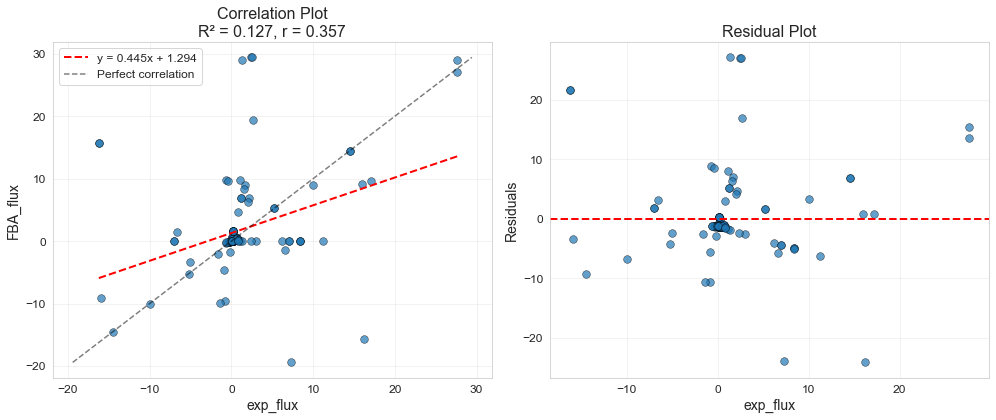

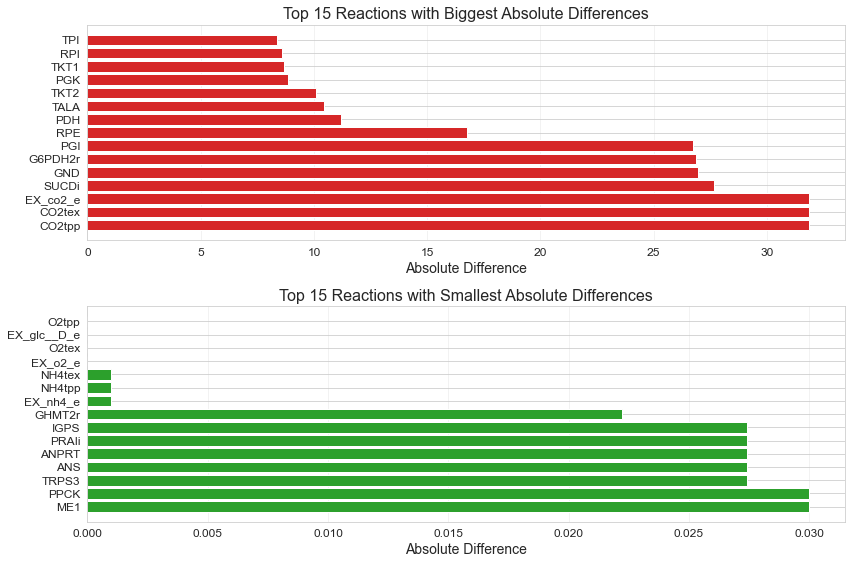

In [34]:
modified_exp_validation_df = compare_fluxomics(fba_results_path=out_path_modified, 
                                      exp_fluxes_path=experimental_fluxes_path)

# Correlation plot
fig, results = plot_flux_correlation(modified_exp_validation_df, 'exp_flux', 'FBA_flux', 
                                    output_path=None, show=True)

# Difference analysis
fig, diff_data = plot_flux_differences(modified_exp_validation_df, 'exp_flux', 'FBA_flux', top_n=15, 
                                      difference_type='absolute', show=True)

### COBRApy

Loaded 2712 FBA flux results
Loaded 143 experimental flux measurements
Merged dataframe has 2712 rows
Matched reactions: 143
Unmatched reactions: 2569


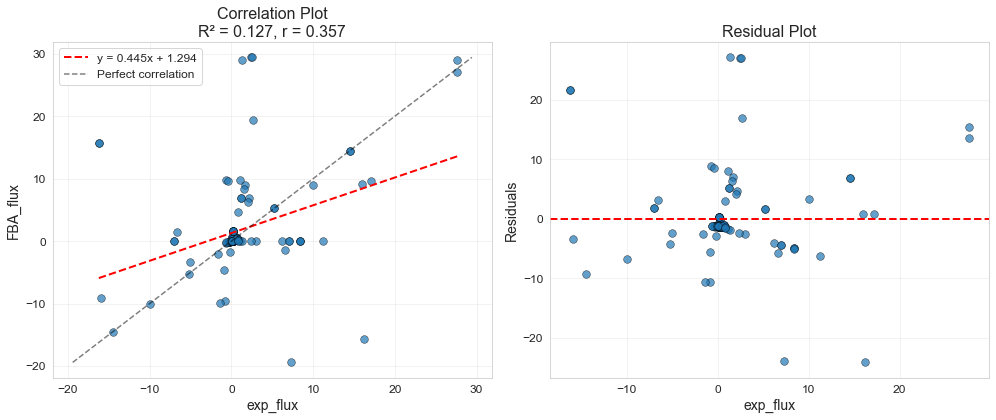

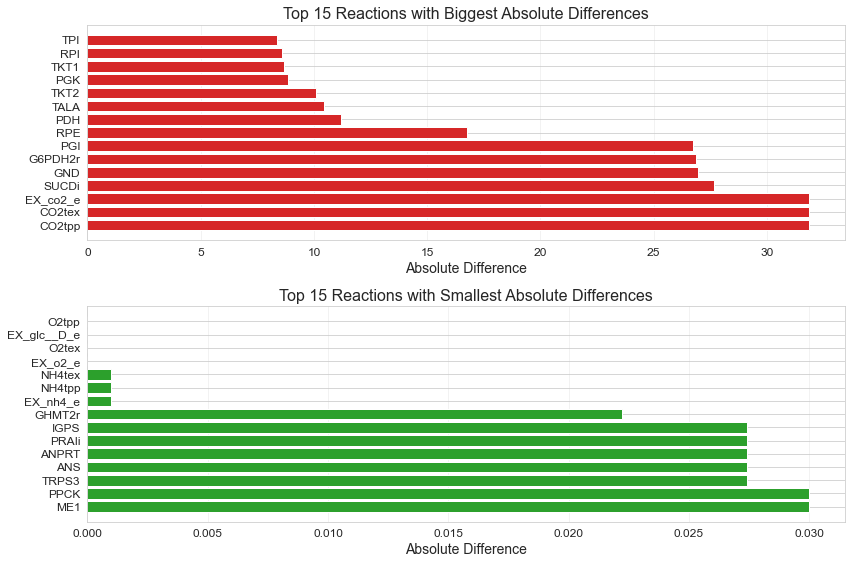

In [35]:
cobrapy_exp_validation_df = compare_fluxomics(fba_results_path=out_path_cobrapy, 
                                      exp_fluxes_path=experimental_fluxes_path)

# Correlation plot
fig, results = plot_flux_correlation(cobrapy_exp_validation_df, 'exp_flux', 'FBA_flux', 
                                    output_path=None, show=True)

# Difference analysis
fig, diff_data = plot_flux_differences(cobrapy_exp_validation_df, 'exp_flux', 'FBA_flux', top_n=15, 
                                      difference_type='absolute', show=True)

### Modified and tuned

Loaded 2712 FBA flux results
Loaded 143 experimental flux measurements
Merged dataframe has 2712 rows
Matched reactions: 143
Unmatched reactions: 2569


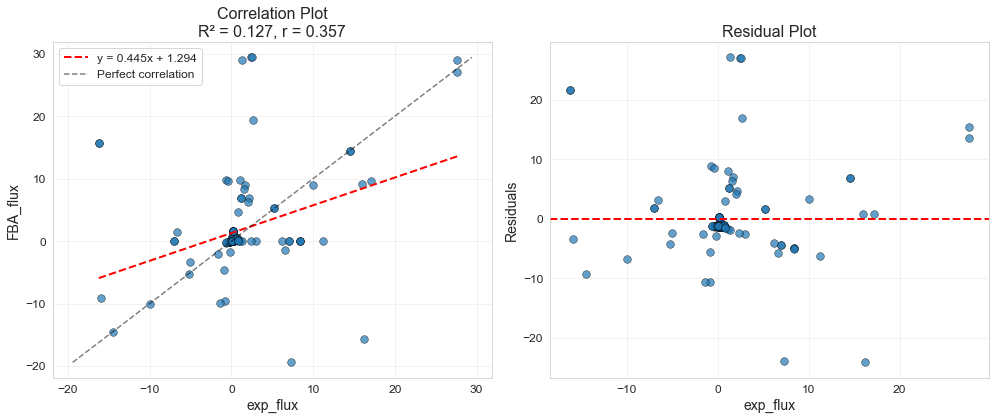

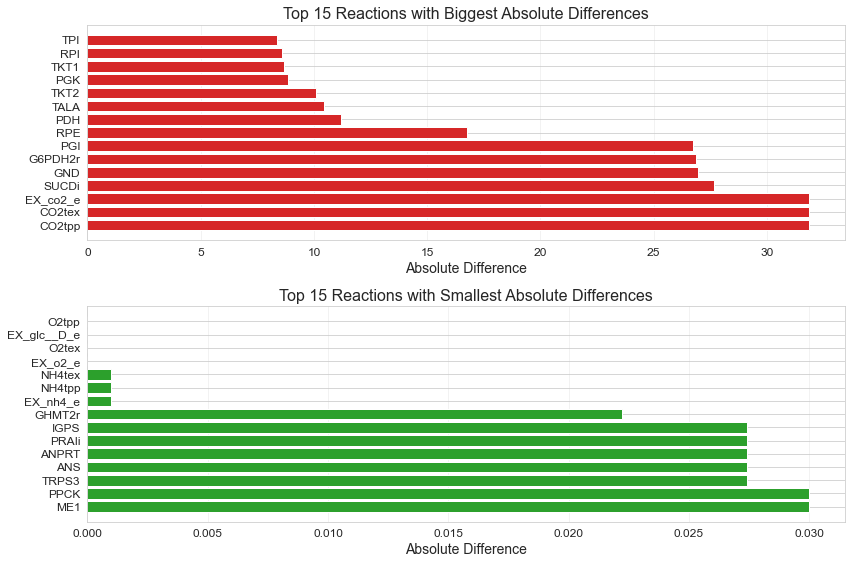

In [36]:
modified_tuned_exp_validation_df = compare_fluxomics(fba_results_path=out_path_modified_tuned, 
                                      exp_fluxes_path=experimental_fluxes_path)

# Correlation plot
fig, results = plot_flux_correlation(modified_tuned_exp_validation_df, 'exp_flux', 'FBA_flux', 
                                    output_path=None, show=True)

# Difference analysis
fig, diff_data = plot_flux_differences(modified_tuned_exp_validation_df, 'exp_flux', 'FBA_flux', top_n=15, 
                                      difference_type='absolute', show=True)

## Comparing kinGEMs fluxes against COBRApy

### kinGEMs vs FBA (both with modified media bounds)

In [37]:
from kinGEMs.plots import kingems_cobrapy_dataframe

cobrapy_kingems_df = kingems_cobrapy_dataframe(kingems_path=out_path_modified, fba_path=out_path_cobrapy)


Loaded 2712 kinGEMs fluxes
Loaded 2712 COBRApy FBA fluxes
Merged dataframe has 2712 rows
Matched reactions: 2712
Unmatched reactions: 0


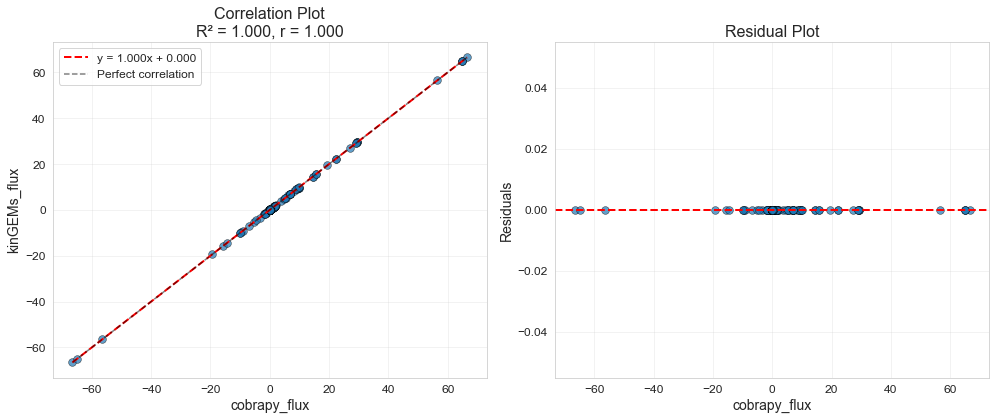

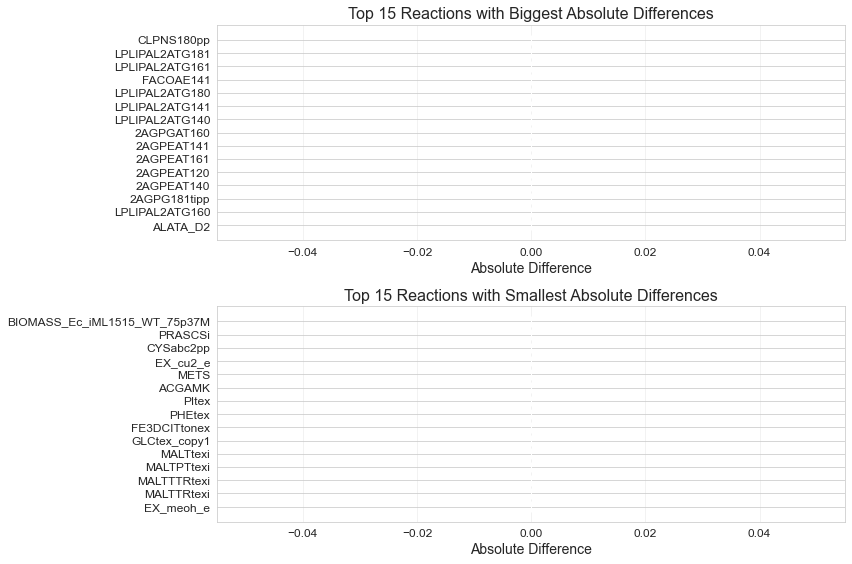

In [38]:
# Correlation plot
fig, results = plot_flux_correlation(cobrapy_kingems_df, 'cobrapy_flux', 'kinGEMs_flux', 
                                    output_path=None, show=True)

# Difference analysis
fig, diff_data = plot_flux_differences(cobrapy_kingems_df, 'cobrapy_flux', 'kinGEMs_flux', top_n=15, 
                                      difference_type='absolute', show=True)

### kinGEMs tuned vs FBA (both with modified media bounds)

In [39]:
from kinGEMs.plots import kingems_cobrapy_dataframe

cobrapy_kingems_tuned_df = kingems_cobrapy_dataframe(kingems_path=out_path_modified_tuned, fba_path=out_path_cobrapy)


Loaded 2712 kinGEMs fluxes
Loaded 2712 COBRApy FBA fluxes
Merged dataframe has 2712 rows
Matched reactions: 2712
Unmatched reactions: 0


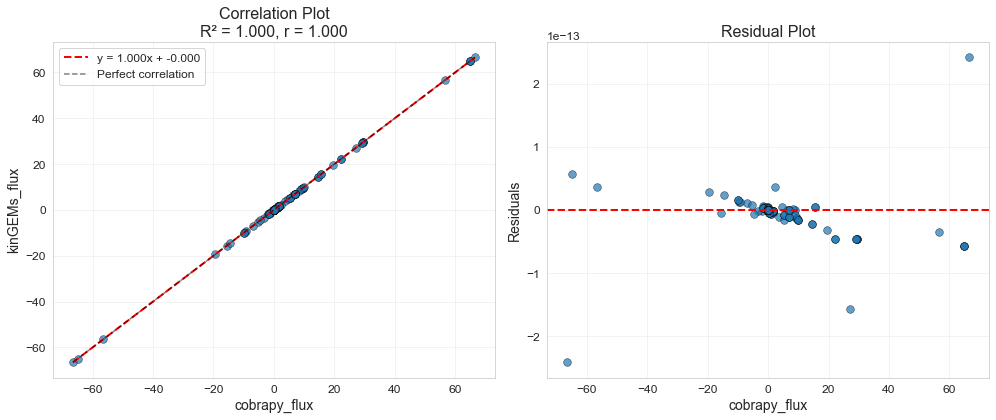

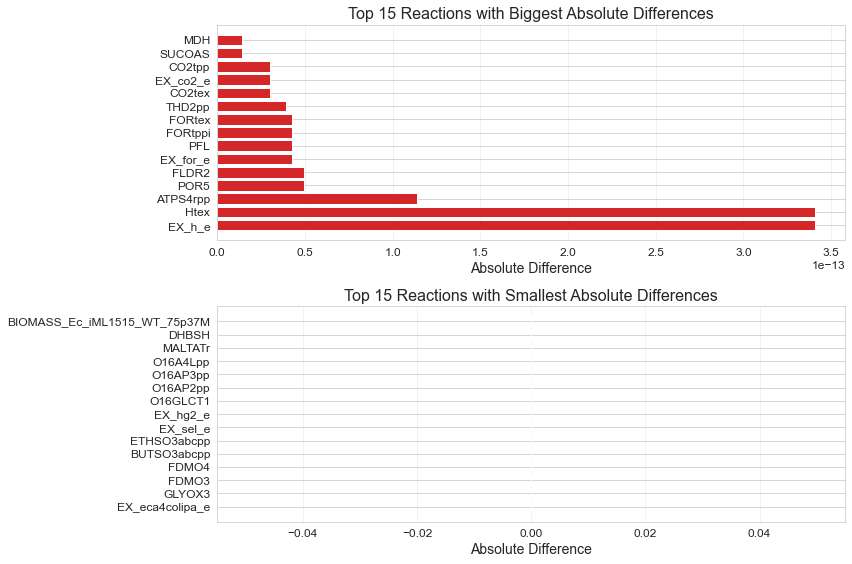

In [40]:
# Correlation plot
fig, results = plot_flux_correlation(cobrapy_kingems_tuned_df, 'cobrapy_flux', 'kinGEMs_flux', 
                                    output_path=None, show=True)

# Difference analysis
fig, diff_data = plot_flux_differences(cobrapy_kingems_tuned_df, 'cobrapy_flux', 'kinGEMs_flux', top_n=15, 
                                      difference_type='absolute', show=True)